# Риск и распределение инвестиций в стартапы: расчёт объёма инвестиций

---

# Цель:
- Написать модель машинного обучения для:
    - рассчёта оптимального объёма инвестиций в стартап;
    - выявление признаков, влияющих на объём инвестиций;
    - сохранение модели для дальнейшего использования (расчёт объёма инвестиций).

In [1]:
import os
import numpy as np
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
plt.rcParams['figure.figsize'] = (8, 7)
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/startup_investment_dataset+rejected_status.csv')

In [3]:
df.head()

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,market_size_estimate,investment_amount,is_rejected
0,Pre-Seed,ClimateTech,US,1.381327e+06,7.223187e+06,9,3,0.000000,6.039942e+06,0.000000e+00,1
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,96087.461835,6.886030e+07,7.203092e+06,0
2,Pre-Seed,HealthTech,LATAM,1.306439e+06,1.022702e+07,5,3,0.000000,1.896208e+07,0.000000e+00,1
3,Idea,E-commerce,US,8.840830e+05,4.531614e+06,3,2,0.000000,7.717272e+06,0.000000e+00,1
4,Series B,E-commerce,US,1.608484e+07,5.189190e+07,10,7,133652.729965,1.415670e+07,1.672645e+07,0


In [4]:
df = df[df['is_rejected'] == 0].drop(columns=['is_rejected', 'market_size_estimate'])
print(f'Общая длина: {len(df)} стартапов')
df.head()

Общая длина: 1948 стартапов


,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,9.608746e+04,7.203092e+06
4,Series B,E-commerce,US,1.608484e+07,5.189190e+07,10,7,1.336527e+05,1.672645e+07
6,Seed,AI/SaaS,Europe,2.492487e+06,1.805700e+07,8,3,1.760057e+05,1.598191e+06
7,Series A,FinTech,US,7.464134e+06,3.169615e+07,11,5,1.219577e+06,4.706876e+06
8,Series A,AI/SaaS,US,3.152825e+06,2.375383e+07,9,2,1.266550e+05,2.755136e+06


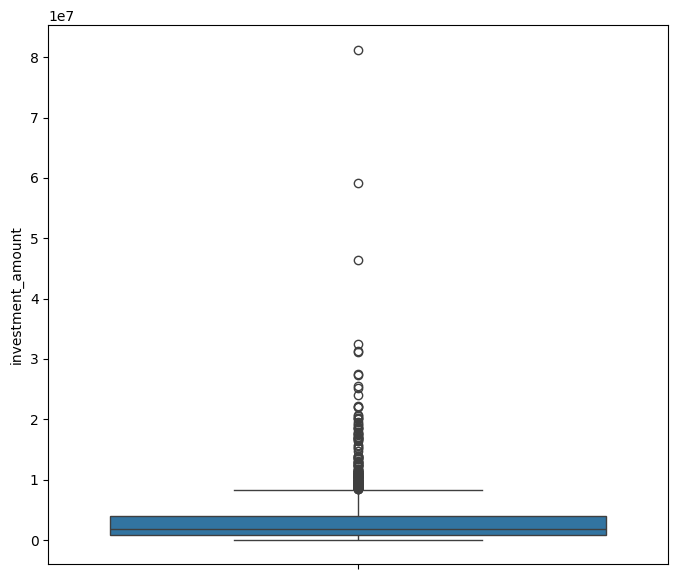

In [5]:
sns.boxplot(y=df['investment_amount'])
plt.show()

In [6]:
# Избавление от выбросов
q_low = df['investment_amount'].quantile(0.01)
q_high = df['investment_amount'].quantile(0.95)

df = df[(df['investment_amount'] >= q_low) & (df['investment_amount'] <= q_high)]

print(f'Отобрано {len(df)} стартапов с объёмом инвестиций от ${int(q_low):,} до ${int(q_high):,}.')

Отобрано 1830 стартапов с объёмом инвестиций от $137,361 до $10,043,519.


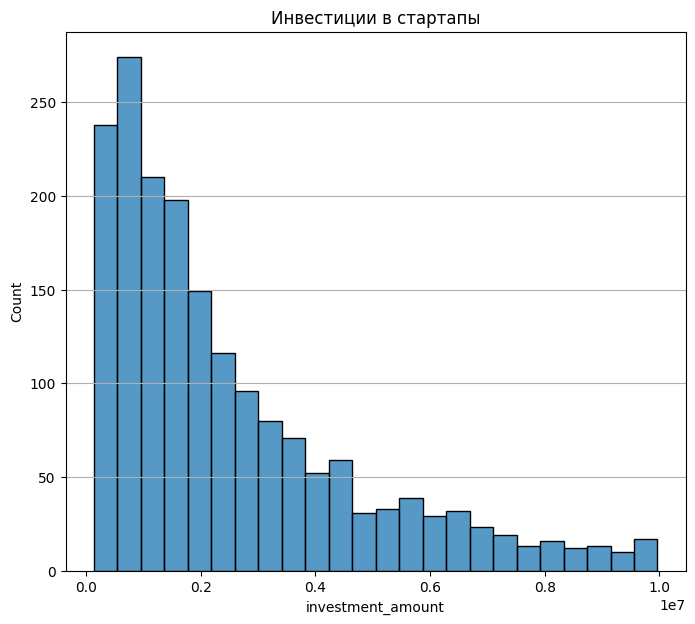

In [7]:
sns.histplot(data=df, x='investment_amount')
plt.title('Инвестиции в стартапы')
plt.grid(axis='y')
plt.show()

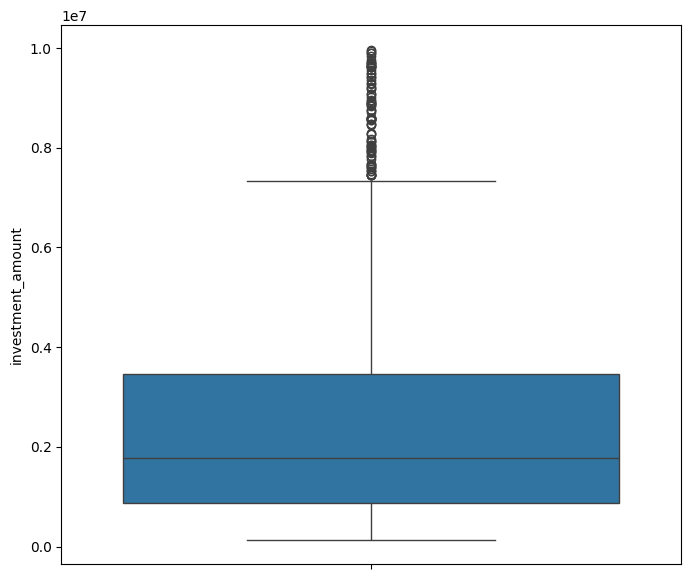

In [8]:
sns.boxplot(y=df['investment_amount'])
plt.show()

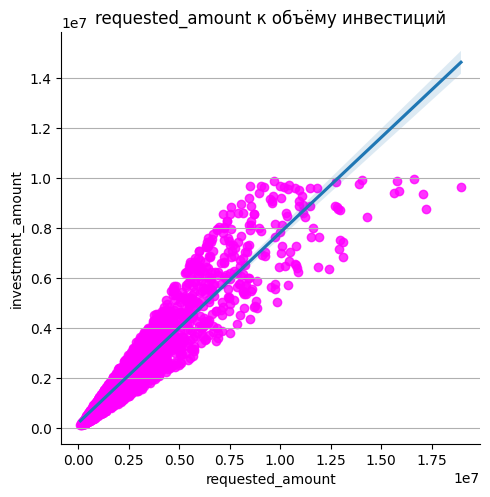

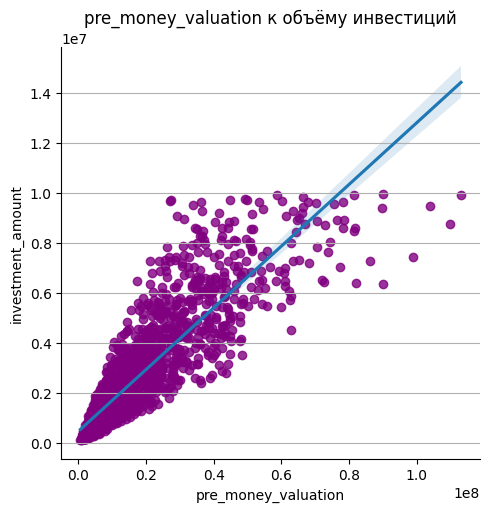

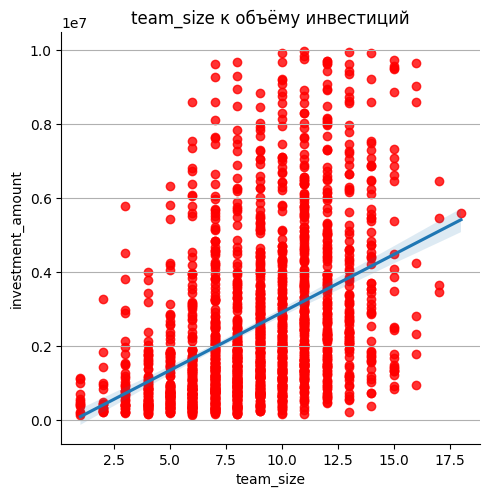

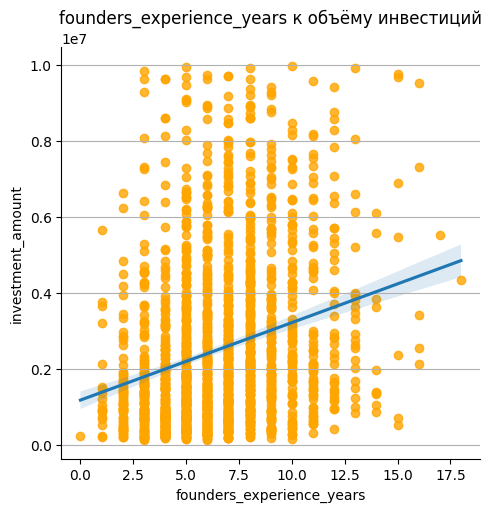

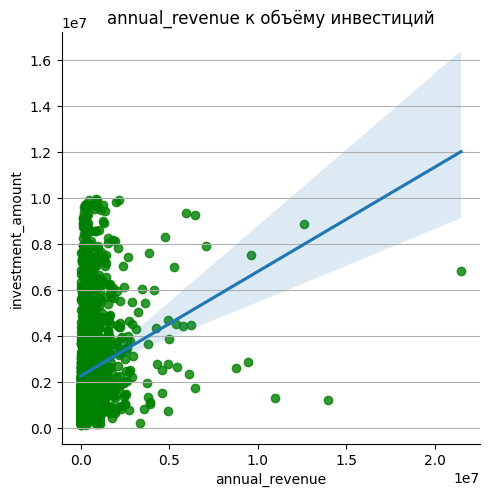

In [9]:
color_map = {
    'requested_amount': 'magenta',
    'team_size': 'red',
    'annual_revenue': 'green',
    'pre_money_valuation': 'purple',
    'founders_experience_years': 'orange'
}

for feature in df.select_dtypes(include=['int64', 'float64']).columns:
    if feature != 'investment_amount':
        sns.lmplot(
            data=df,
            x=feature,
            y='investment_amount',
            scatter_kws={'color': color_map.get(feature, 'gray')},
        )
        plt.grid(axis='y')
        plt.title(f'{feature} к объёму инвестиций')
        plt.show()

# Моделирование

In [10]:
import mlflow
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.cluster import KMeans

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## Feature engineering

Добавление новых признаков для лучшего обучения модели:

- Добавление отношений денежных признаков;
- Добавление производных признаков от команды;
- Бизнес-признаки;
- Логарифмирование денежных и остальных числовых признаков;

In [11]:
def create_additional_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    eps = 1

    # --- Отношения денежных признаков ---
    df['requested_to_valuation'] = (df['requested_amount'] / (df['pre_money_valuation'] + eps))
    df['revenue_to_valuation'] = (df['annual_revenue'] / (df['pre_money_valuation'] + eps))
    df['revenue_per_employee'] = (df['annual_revenue'] / (df['team_size'] + eps))

    # --- Команда ---
    df['experience_per_member'] = (df['founders_experience_years'] / (df['team_size'] + eps))
    df['team_maturity'] = (df['team_size'] * df['founders_experience_years'])

    # --- Бизнес-флаги ---
    df['early_stage'] = (df['startup_stage'].isin(['Idea', 'Pre-Seed']).astype(int))
    df['is_us_market'] = ((df['region'] == 'US').astype(int))

    # --- Логарифмы денежных признаков ---

    numeric_features = df.select_dtypes(include=['int64', 'float64'])

    for col in numeric_features:
        if col in df.columns:
            df[f'{col}_log'] = np.log1p(df[col])

    # Очистка проблем после деления
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df

In [12]:
df = create_additional_features(df)
df.head()

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,...,founders_experience_years_log,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,9.608746e+04,7.203092e+06,0.255296,...,2.197225,11.473025,15.790021,0.227371,0.003146,8.834102,0.451985,4.653960,0.0,0.693147
6,Seed,AI/SaaS,Europe,2.492487e+06,1.805700e+07,8,3,1.760057e+05,1.598191e+06,0.138034,...,1.386294,12.078277,14.284384,0.129303,0.009700,9.881098,0.287682,3.218876,0.0,0.000000
7,Series A,FinTech,US,7.464134e+06,3.169615e+07,11,5,1.219577e+06,4.706876e+06,0.235490,...,1.791759,14.014015,15.364535,0.211468,0.037755,11.529118,0.348307,4.025352,0.0,0.693147
8,Series A,AI/SaaS,US,3.152825e+06,2.375383e+07,9,2,1.266550e+05,2.755136e+06,0.132729,...,1.098612,11.749230,14.828978,0.124630,0.005318,9.446716,0.182322,2.944439,0.0,0.693147
9,Seed,FinTech,US,2.722484e+06,1.256703e+07,8,8,3.605893e+05,1.459347e+06,0.216637,...,2.197225,12.795498,14.193501,0.196091,0.028289,10.598295,0.635989,4.174387,0.0,0.693147


In [13]:
# Логарифмирование целевой переменной
df['investment_amount_log'] = np.log1p(df['investment_amount'])

target = 'investment_amount_log'

# Кластеризация стартапов

- В распределении объёмов инвестиций наблюдается сильный скос вправо, что говорит о наличии отлично высоких объёмах, следовательно модель не сможет стабильно работать на всей выборке
- Кластеризация стартапов поможет разбить их на группы, на каждую из которых можно создать уникальную регрессионную модель.
- Идея кластеризации заключается в разделении стартапов на сегменты: __дешёвые__, __средние__ и ___дорогие__, при том __без использования целевой переменной__, поскольку кластер будет являться __прокси-признаком__, вызывающим:
    - Утечку данных;
    - Невозможность присвоить кластер при оценке новых стартапов.

В качестве признаков для сегментации используются:

- `requested_amount` — запрошенный объём инвестиций;
- `pre_money_valuation` — предварительная оценка стартапа;
- `annual_revenue` — существующая годовая выручка стартапа;
- `team_size` — количество сотрудников/участников;
- `founders_experience_years` — опыт сотрудников/участников.

In [14]:
cluster_preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cluster_preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [15]:
cluster_features = [
    'requested_amount',
    'pre_money_valuation',
    'annual_revenue',
    'team_size',
]

kmeans = Pipeline(steps=[
    ('preprocessor', cluster_preprocessor),
    ('kmeans', KMeans(n_clusters=4, random_state=42))
])

kmeans.fit(df[cluster_features])

clusters = kmeans.predict(
    df[cluster_features]
)

df['cluster'] = clusters
df.head()

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,...,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log,cluster
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,9.608746e+04,7.203092e+06,0.255296,...,11.473025,15.790021,0.227371,0.003146,8.834102,0.451985,4.653960,0.0,0.693147,0
6,Seed,AI/SaaS,Europe,2.492487e+06,1.805700e+07,8,3,1.760057e+05,1.598191e+06,0.138034,...,12.078277,14.284384,0.129303,0.009700,9.881098,0.287682,3.218876,0.0,0.000000,1
7,Series A,FinTech,US,7.464134e+06,3.169615e+07,11,5,1.219577e+06,4.706876e+06,0.235490,...,14.014015,15.364535,0.211468,0.037755,11.529118,0.348307,4.025352,0.0,0.693147,0
8,Series A,AI/SaaS,US,3.152825e+06,2.375383e+07,9,2,1.266550e+05,2.755136e+06,0.132729,...,11.749230,14.828978,0.124630,0.005318,9.446716,0.182322,2.944439,0.0,0.693147,1
9,Seed,FinTech,US,2.722484e+06,1.256703e+07,8,8,3.605893e+05,1.459347e+06,0.216637,...,12.795498,14.193501,0.196091,0.028289,10.598295,0.635989,4.174387,0.0,0.693147,3


In [16]:
display(
    df[
        df.cluster==2
    ][[
        'startup_stage',
        'requested_amount',
        'pre_money_valuation',
        'annual_revenue',
        'team_size',
        'investment_amount'
    ]].head(15)
)

,startup_stage,requested_amount,pre_money_valuation,annual_revenue,team_size,investment_amount
87,Series A,1.288858e+06,9.435831e+06,4.908132e+06,14,7.243237e+05
172,Series B,7.238961e+06,5.097226e+07,2.147011e+07,10,6.839447e+06
240,Series A,2.442764e+06,1.199705e+07,4.329527e+06,9,2.789293e+06
298,Series B,6.494890e+06,4.220368e+07,4.279628e+06,13,4.346944e+06
379,Series B,7.204680e+06,3.107630e+07,9.617092e+06,14,7.538984e+06
634,Series A,7.142489e+06,3.506903e+07,5.403820e+06,7,4.523112e+06
654,Series A,9.665539e+06,3.638530e+07,6.482310e+06,7,9.272808e+06
687,Series A,2.635845e+06,1.879836e+07,6.137079e+06,13,2.345120e+06
818,Series B,2.373313e+06,1.724016e+07,1.099183e+07,10,1.306727e+06
1055,Series B,1.273084e+07,7.041236e+07,1.259119e+07,15,8.867364e+06


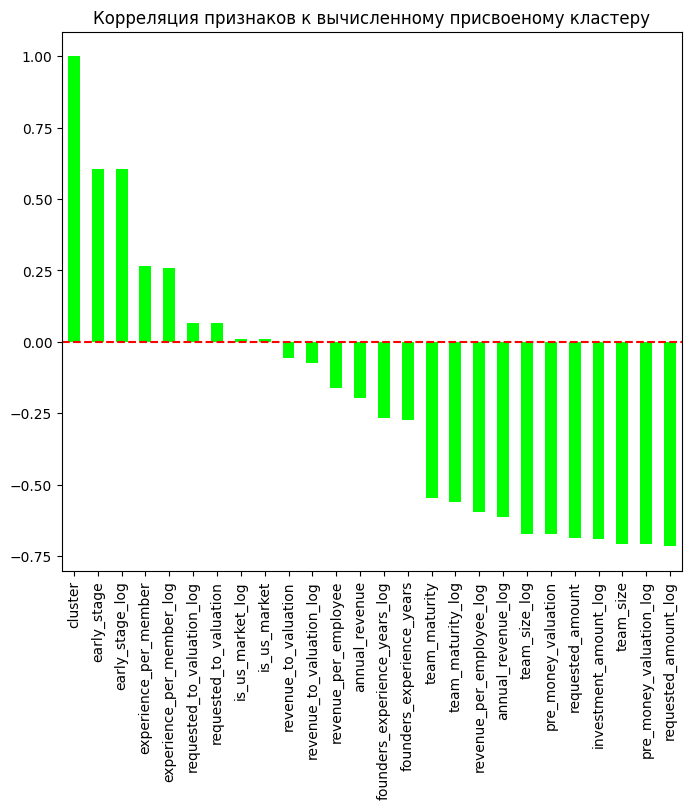

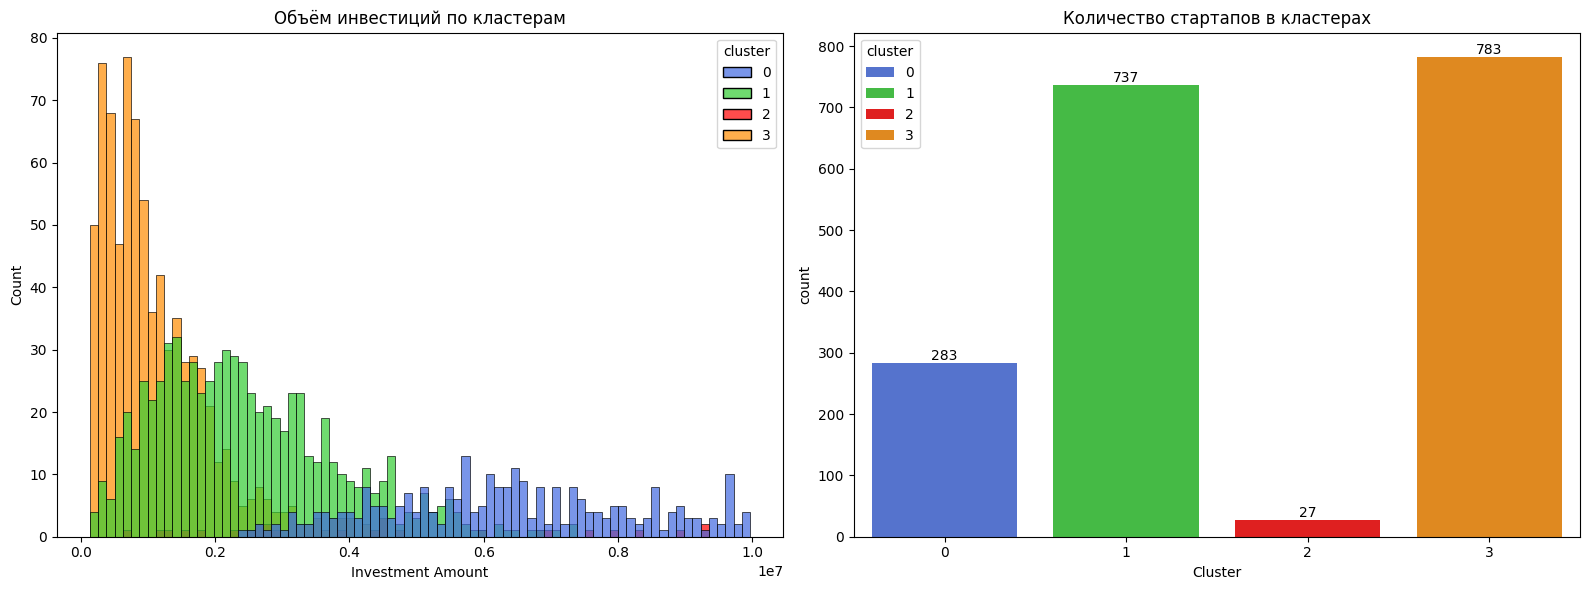

In [17]:
ax = (
    df.drop(columns=['investment_amount'])
        .corr(numeric_only=True)['cluster']
        .sort_values(ascending=False).plot(kind='bar', color='lime')
     )
plt.axhline(y=0, linestyle='--', c='red')
plt.title('Корреляция признаков к вычисленному присвоеному кластеру')
plt.show()

# ---------------------------------

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Clusters palette
palette = {
    0: "royalblue",
    1: "limegreen",
    2: "red",       # обязательно красный
    3: "darkorange"
}

df_sorted = df.sort_values(by='investment_amount', ascending=True)

sns.histplot(data=df_sorted, x='investment_amount', hue='cluster', palette=palette, alpha=.7, ax=axes[0], bins=80)
axes[0].set_title('Объём инвестиций по кластерам')
axes[0].set_xlabel('Investment Amount')

sns.countplot(data=df, x='cluster', hue='cluster', palette=palette, ax=axes[1])
# Подписи над столбцами
for container in axes[1].containers:
    axes[1].bar_label(container)
axes[1].set_title('Количество стартапов в кластерах')
axes[1].set_xlabel('Cluster')
plt.tight_layout()

plt.show()

In [18]:
### print('Процентное соотношение сегментов:\n', df['cluster'].value_counts(normalize=True).sort_index() * 100)

cluster_stats = df.groupby('cluster').mean(numeric_only=True).sort_values(by='requested_amount')
display(cluster_stats)

,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,revenue_to_valuation,revenue_per_employee,experience_per_member,...,founders_experience_years_log,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log
cluster,,,,,,,,,,,,,,,,,,,,,
3,1.328832e+06,7.027602e+06,6.196679,5.696041,1.711883e+05,1.118852e+06,0.200121,0.025282,22460.969191,0.858510,...,1.832053,5.021170,13.674531,0.181310,0.023769,4.193187,0.591494,3.437911,0.416951,0.318688
1,2.871011e+06,1.503571e+07,10.580733,6.982361,6.629229e+05,2.457649e+06,0.199885,0.062478,58850.251217,0.612205,...,2.015845,12.483183,14.541250,0.181127,0.056017,10.139374,0.466600,4.219652,0.027274,0.298138
2,5.732619e+06,3.148084e+07,11.185185,7.333333,7.171226e+06,4.538247e+06,0.184798,0.329926,610706.817031,0.605862,...,2.035616,15.688896,15.123216,0.168658,0.261888,13.207060,0.459982,4.288248,0.000000,0.282393
0,7.879639e+06,4.494055e+07,10.756184,7.586572,7.161906e+05,6.322830e+06,0.183886,0.017137,62929.286089,0.669976,...,2.092818,12.952311,15.612786,0.167810,0.016869,10.538501,0.500140,4.306311,0.007348,0.325755


### > Анализ 2-го кластера

In [19]:
print(df['cluster'].value_counts())
print(df['cluster'].value_counts(normalize=True)*100)

cluster
3    783
1    737
0    283
2     27
Name: count, dtype: int64
cluster
3    42.786885
1    40.273224
0    15.464481
2     1.475410
Name: proportion, dtype: float64


In [20]:
df[df['cluster'] == 2].head(7)

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,...,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log,cluster
87,Series A,EdTech,US,1.288858e+06,9.435831e+06,14,4,4.908132e+06,7.243237e+05,0.136592,...,15.406404,13.492995,0.128034,0.418815,12.698357,0.236389,4.043051,0.0,0.693147,2
172,Series B,HealthTech,Asia,7.238961e+06,5.097226e+07,10,4,2.147011e+07,6.839447e+06,0.142018,...,16.882172,15.738218,0.132797,0.351510,14.484277,0.310155,3.713572,0.0,0.000000,2
240,Series A,E-commerce,US,2.442764e+06,1.199705e+07,9,7,4.329527e+06,2.789293e+06,0.203614,...,15.280969,14.841299,0.185328,0.308133,12.978386,0.530628,4.158883,0.0,0.693147,2
298,Series B,HealthTech,Europe,6.494890e+06,4.220368e+07,13,18,4.279628e+06,4.346944e+06,0.153894,...,15.269377,15.284984,0.143142,0.096586,12.630323,0.826679,5.459586,0.0,0.000000,2
379,Series B,AI/SaaS,Europe,7.204680e+06,3.107630e+07,14,11,9.617092e+06,7.538984e+06,0.231838,...,16.079053,15.835598,0.208508,0.269620,13.371004,0.550046,5.043425,0.0,0.000000,2
634,Series A,E-commerce,US,7.142489e+06,3.506903e+07,7,5,5.403820e+06,4.523112e+06,0.203669,...,15.502617,15.324711,0.185375,0.143313,13.423177,0.485508,3.583519,0.0,0.693147,2
654,Series A,HealthTech,Asia,9.665539e+06,3.638530e+07,7,3,6.482310e+06,9.272808e+06,0.265644,...,15.684588,16.042597,0.235581,0.163952,13.605147,0.318454,3.091042,0.0,0.000000,2


---

## Кластеризация стартапов

Для дополнительной сегментации стартапов была проведена кластеризация методом K-Means. Целью являлось выделение групп компаний со схожими финансовыми и организационными характеристиками для дальнейшего использования в инвестиционном пайплайне.

Кластеризация позволяет разделить стартапы на группы со схожим профилем риска и масштаба, а затем использовать специализированные модели регрессии для каждого сегмента отдельно.

### Использованные признаки

Для обучения использовались признаки, отражающие зрелость компании и масштаб бизнеса:

- `requested_amount`
- `pre_money_valuation`
- `annual_revenue`
- `team_size`
- `founders_experience_years`

При построении модели не использовались:

- `investment_amount`

Это исключает утечку данных (data leakage), поскольку будущий объём инвестиций не участвует в формировании сегментов.

---

## Распределение стартапов по кластерам

| Кластер | Количество | Доля |
|----------|------------:|------:|
| 3 | 783 | 42.8% |
| 1 | 737 | 40.3% |
| 0 | 283 | 15.5% |
| 2 | 27 | 1.5% |

Основную часть выборки составляют два массовых сегмента: ранние и зрелые стартапы. Также были обнаружены более крупные компании и небольшой специализированный сегмент высокодоходных стартапов.

---

## Средние значения ключевых признаков

| Кластер | Requested Amount | Pre-money Valuation | Annual Revenue | Investment Amount |
|----------|----------------:|--------------------:|----------------:|------------------:|
| 3 | 1.33M | 7.03M | 0.17M | 1.12M |
| 1 | 2.87M | 15.04M | 0.66M | 2.46M |
| 0 | 7.88M | 44.94M | 0.72M | 6.32M |
| 2 | 5.73M | 31.48M | 7.17M | 4.54M |

Наблюдается закономерное увеличение размеров компаний:

```text
Cluster 3 → Cluster 1 → Cluster 0

ранние → зрелые → крупные
```

Однако был обнаружен дополнительный сегмент:

```text
Cluster 2

высокодоходные scale-up компании
```

---

## Интерпретация кластеров

### Cluster 3 — Early Stage Startups

Наиболее ранний сегмент.

Характеристики:

- высокая доля Idea и Pre-Seed
- небольшие команды
- низкий объём выручки
- минимальные объёмы инвестиций
- высокая неопределённость

Этот кластер соответствует типичным ранним стартапам, находящимся на стадии поиска продукта и рынка.

---

### Cluster 1 — Mature Startups

Основной сегмент выборки.

Характеристики:

- преобладают стадии Seed и Series A
- сформированные команды
- умеренные показатели оценки
- средний инвестиционный объём

Представляет типичный венчурный рынок.

---

### Cluster 0 — Large Investment Startups

Крупные инвестиционные проекты.

Характеристики:

- высокие оценки компаний
- крупные команды
- значительные инвестиционные запросы
- поздние стадии развития

Данный сегмент соответствует стартапам, требующим повышенного объёма капитала и более серьёзной оценки рисков.

---

### Cluster 2 — High-Revenue Scale-Up Startups

Наиболее редкий сегмент (~1.5%).

Особенность данного кластера — аномально высокий объём выручки:

- Annual Revenue ≈ 7.17M
- преобладают стадии Series A / Series B
- опытные команды
- высокий уровень зрелости бизнеса

Несмотря на относительно небольшой размер сегмента, алгоритм K-Means выделил данные компании отдельно.

Вероятная интерпретация:

это не выбросы, а специализированный класс зрелых компаний, уже имеющих существенную выручку и находящихся на стадии масштабирования бизнеса (scale-up).

---

## Вывод

Кластеризация выявила устойчивую структуру рынка стартапов и выделила четыре различных сегмента компаний:

- ранние стартапы
- зрелые компании
- крупные инвестиционные проекты
- высокодоходные scale-up стартапы

Полученная сегментация может использоваться как дополнительный этап инвестиционного пайплайна:

```text
Startup Features
        ↓
Cluster Prediction
        ↓
Cluster-specific Regressor
        ↓
Investment Amount Prediction
```

Такой подход позволяет строить специализированные модели под разные типы компаний и потенциально снижать ошибку прогнозирования инвестиционного объёма.

In [21]:
TODO

NameError: name 'TODO' is not defined

## Разбиение и преобразование данных

In [ ]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
target_remove_cols = ['investment_amount', 'investment_amount_log']

num_features = [c for c in num_features if c not in target_remove_cols]

In [ ]:
X = df.drop(columns=['investment_amount', 'investment_amount_log'])
y = df[target]

print(f'> Featrues {X.shape}: \n{X.columns.tolist()}\n')
print(f'> Target {y.shape}: \n{target}')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), num_features),
    ('encoder', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

preprocessor

In [ ]:
try:
    joblib.dump(preprocessor, '../src/models/preprocessors/regression_preprocessor')
    print('Препроцессор сохранён.')
    joblib.dump(kmeans, '../src/models/models_to_use/clusteriser.joblib')
    print('Модель кластеризации сохранена.')
except Exception as e:
    print(f'Не удалось сохранить препроцессор/модель кластеризации.\n{e}')

In [ ]:
BREAKDOWN

In [ ]:
emerging_startups = df[df['cluster'] == 1]
growth_startups = df[df['cluster'] == 0]
large_startups = df[df['cluster'] == 2]

print(f'EMERGING: {len(emerging_startups)}\nGROWTH: {len(growth_startups)}\nHIGH CAPITAL: {len(large_startups)}')

# Обучение моделей машинного обучения

In [ ]:
MODELS = {
    'ridge': (
        Ridge(random_state=42),
        {
            'model__alpha': [0.1, 1.0, 10.0]
        }
    ),

    'lasso': (
        Lasso(random_state=42),
        {
            'model__alpha': [0.01, 0.1, 1.0]
        }
    ),

    'random_forest': (
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        {
            'model__n_estimators': [200, 500],
            'model__max_depth': [None, 10, 20]
        }
    ),

    'gboost': (
        GradientBoostingRegressor(
            random_state=42
        ),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5]
        }
    ),

    'xgb': (
        XGBRegressor(
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 5, 7],
            'model__min_child_weight': [1, 5],
            'model__subsample': [0.7, 0.9],
            'model__colsample_bytree': [0.7, 0.9],
            'model__reg_alpha': [0, 0.1, 1],
            'model__reg_lambda': [1, 5]
        }
    ),

    'lgbm': (
        LGBMRegressor(
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [-1, 5, 10],
            'model__num_leaves': [31, 63],
            'model__min_child_samples': [20, 50],
            'model__subsample': [0.7, 0.9],
            'model__colsample_bytree': [0.7, 0.9]
        }
    )
}

MODELS.keys()

In [ ]:
trained_models = []

def train_models(X_train, X_test, y_train, y_test, preprocessor, report_dir="artifacts/reports/regression"):
    os.makedirs(report_dir, exist_ok=True)

    results = []

    for model_name, (model, param_grid) in MODELS.items():
        print("\n" + "=" * 60)
        print(f"MODEL: {model_name.upper()}")
        print("=" * 60)

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        with mlflow.start_run(run_name=model_name):
            mlflow.set_tag("task", "regression")
            mlflow.set_tag("model_name", model_name)

            print("GridSearchCV running...")

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring='neg_root_mean_squared_error',
                cv=5,
                n_jobs=-1
            )

            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_
            
            # Predictions
            y_pred_log = best_model.predict(X_test)

            y_pred = np.expm1(y_pred_log)
            y_true = np.expm1(y_test)

            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            r2 = r2_score(y_true, y_pred)
            mape = np.mean(np.abs((y_true-y_pred)/ y_true))

            print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.3f} | MAPE: {mape:.2%}")

            # Save model into list 
            trained_models.append(best_model)

            # MLflow
            mlflow.log_params(grid.best_params_)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("r2", r2)
            mlflow.log_metric("cv_rmse", abs(grid.best_score_))
            mlflow.sklearn.log_model(best_model, "model")
            
            # Report
            report_path = os.path.join(
                report_dir,
                f"{model_name}_report.txt"
            )

            with open(report_path, "w", encoding="utf-8") as f:
                f.write(f"MODEL: {model_name}\n")
                f.write(f"RMSE: {rmse:.2f}\n")
                f.write(f"MAE: {mae:.2f}\n")
                f.write(f"R2: {r2:.4f}\n\n")
                f.write("BEST PARAMS:\n")

                for k, v in grid.best_params_.items():
                    f.write(f"{k}: {v}\n")

            mlflow.log_artifact(report_path)

            results.append({
                'model': model_name,
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'mape': mape
            })

    results = pd.DataFrame(results).sort_values(by='mape')

    return results

In [ ]:
results = train_models(
    X_train,
    X_test,
    y_train,
    y_test,
    preprocessor
)

display(results)

In [ ]:
model = trained_models[3]
display(model) # GradientBoostingRegressor

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# MAPE (важно защититься от деления на 0)
mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

In [ ]:
df['investment_amount'].describe()

# Лучшая модель: <span style='color:green'>_GradientBoostingRegressor_</span>

**Метрики:**
- MAE = <span style='color:green'>522,815.89</span>
- RMSE = <span style='color:green'>754,051.81</span>
- R^2 = <span style='color:green'>0.8924</span>
- MAPE = <span style='color:green'>22,04%</span>

---
## Optuna

Подбор лучших гиперпараметров для RandomForest

In [ ]:
estimator = model.named_steps['model']
display(estimator)

# Результаты RandomForest

| Метрика | Значение | Интерпретация                                                                                                               |
| ------- | -------- | -------- |
| Log-RMSE | 0.1752 | Среднеквадратичная ошибка в **лог-пространстве** низкая -> модель точно улавливает относительные различия между стартапами. |
| Log-MAE  | 0.1415 | Средняя абсолютная ошибка в логах небольшая -> большинство предсказаний близки к таргету. |
| R^2       | 0.9666 | Модель объясняет **96.7% вариации** лог-инвестиций -> порядок величины инвестиций предсказывается очень точно. |
| MAE      | $363,268 | В среднем предсказание отклоняется на __~363 тыс $__ от реальной суммы. |
| RMSE     | $579,173 | Среднеквадратичная ошибка в долларах отражает влияние крупных инвестиций, но в целом точность высока. |
| MAPE     | 14.6% | Ошибка составляет примерно 14.6% от реальных инвестиций — прогноз достаточно надёжный для практических решений. |

**Интерпретация:**  
1. В среднем предсказание отклоняется на $363k от реальной суммы, что делает прогноз оптимальным для ориентирования.  
2. Ошибка составляет ~14.6% от реальных инвестиций, подходя для стратегического планирования.  
3. RandomForest хорошо улавливает нелинейные зависимости между признаками и объёмом инвестиций, сохраняя высокое объяснение дисперсии в логарифме.

---

# Рекомендации по использованию модели

<span style='color:red'>**При использовании прогнозов RandomForest учитывать среднюю ошибку**:</span>
- **Прогноз = <u>predict ± $363,268**</u> — среднее отклонение для типичного стартапа.  
- Для особо крупных стартапов ошибка может быть больше (отражается в RMSE <u>**$579,173**</u>).</span> 
- Модель особенно надёжна для оценки **порядка величины и относительных различий** между стартапами.  
- При стратегическом планировании <span style='color: orange'><u>использовать прогноз как ориентир, а не как точную сумму сделки</u></span>.


In [ ]:
# try:
#     joblib.dump(rf_pipeline, '../src/models/rf_regressor.joblib')
#     print('Финальная модель сохранена в src/models/rf_regressor.joblib.')
# except Exception as e:
#     print(f'Не удалось сохранить модель:\n{e}')
print('MODEL MUST BE SAVED HERE.')